# Prefix/Template Spectral Variability Test (GPT-2 Large)

This notebook loads the latest `gpt2_prefix_template_variability_gpt2-large_*.json` artifact and visualizes how spectral/edit-related metrics move across the 20 prefix-template runs.

In [23]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [24]:
artifact_pattern = 'gpt2_prefix_template_variability_gpt2-large_*.json'

# Find analysis_out from the current working directory upward (works from repo root or notebooks/).
candidate_dirs = []
for base in [Path.cwd(), *Path.cwd().parents]:
    analysis_dir = base / 'analysis_out'
    if analysis_dir.is_dir():
        candidate_dirs.append(analysis_dir)

if not candidate_dirs:
    candidate_dirs = [Path('analysis_out')]

candidates = []
for analysis_dir in candidate_dirs:
    candidates.extend(sorted(analysis_dir.glob(artifact_pattern)))

if not candidates:
    searched = ', '.join(str(p) for p in candidate_dirs)
    raise FileNotFoundError(
        f"No GPT-2 large variability JSON found. Pattern='{artifact_pattern}'. Searched in: {searched}"
    )

artifact = sorted(set(candidates))[-1]
print(f'Using artifact: {artifact}')

data = json.loads(artifact.read_text(encoding='utf-8'))
metadata = data.get('metadata', {})
edited_layer = int(metadata.get('target_layer', -1))
print('Model:', metadata.get('model'))
print('Case idx:', metadata.get('case_idx'), 'Case id:', metadata.get('case_id'))
print('Subject:', metadata.get('subject'))
print('Edited layer:', edited_layer)

Using artifact: /data/olexa/Latium/analysis_out/gpt2_prefix_template_variability_gpt2-large_2026-03-23_16-24-21.json
Model: gpt2-large
Case idx: 0 Case id: 0
Subject: Danielle Darrieux
Edited layer: 12


In [25]:
def safe_float(value, default=np.nan):
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)


def edited_layer_delta(run, signal_key, layer):
    block = (run.get('spectral_delta') or {}).get(signal_key) or {}
    for k, v in block.items():
        if int(k) == int(layer):
            return safe_float(v)
    return np.nan


layer_metric_cols = [
    'rome_hybrid_scores',
    'sv_z_scores',
    'sv_ratio_scores',
    'pcs_composite_rank_scores',
    'sv_pcs_contradiction_scores',
    'pcs_neighbor_shift_scores',
]

rows = []
layer_rows = []
for i, r in enumerate(data.get('runs', [])):
    if r.get('error'):
        continue

    run_index = int(r.get('run_index', i))
    run_name = r.get('run_name')
    prefix_mode = r.get('prefix_mode')
    spectral_delta = r.get('spectral_delta') or {}

    layer_keys = sorted(
        {
            int(k)
            for metric in layer_metric_cols
            for k in (spectral_delta.get(metric) or {}).keys()
        }
    )

    for layer in layer_keys:
        layer_entry = {
            'run_index': run_index,
            'run_name': run_name,
            'prefix_mode': prefix_mode,
            'layer': layer,
        }
        for metric in layer_metric_cols:
            layer_entry[metric] = safe_float((spectral_delta.get(metric) or {}).get(str(layer), np.nan))
        layer_rows.append(layer_entry)

    rows.append({
        'run_index': run_index,
        'run_name': run_name,
        'prefix_mode': prefix_mode,
        'rome_success': bool(r.get('rome_success', False)),
        'target_prob_delta': safe_float(r.get('target_prob_delta', np.nan)),
        'update_spectral_norm': safe_float(r.get('update_spectral_norm', np.nan)),
        'edited_layer_hybrid_score': safe_float(r.get('edited_layer_hybrid_score', np.nan)),
        'hybrid_margin_to_top': safe_float(r.get('hybrid_margin_to_top', np.nan)),
        'presence_confidence': safe_float((r.get('edit_presence_detection') or {}).get('confidence')),
        'rome_hybrid_delta_at_edit_layer': edited_layer_delta(r, 'rome_hybrid_scores', edited_layer),
        'sv_z_delta_at_edit_layer': edited_layer_delta(r, 'sv_z_scores', edited_layer),
        'sv_ratio_delta_at_edit_layer': edited_layer_delta(r, 'sv_ratio_scores', edited_layer),
    })

df = pd.DataFrame(rows).sort_values('run_index').reset_index(drop=True)
layer_df = pd.DataFrame(layer_rows).sort_values(['run_index', 'layer']).reset_index(drop=True)

if df.empty:
    raise ValueError('No successful runs found in artifact.')
if layer_df.empty:
    raise ValueError('No layer-wise spectral data found in artifact.')

baseline_rows = df[df['run_name'].str.contains('baseline', case=False, na=False)]
if not baseline_rows.empty:
    baseline_run_index = int(baseline_rows.iloc[0]['run_index'])
else:
    baseline_run_index = int(df['run_index'].min())

baseline_run_name = str(df.loc[df['run_index'] == baseline_run_index, 'run_name'].iloc[0])
print(f'Baseline run: {baseline_run_index} ({baseline_run_name})')
print(f'Layer metrics available: {layer_metric_cols}')

layer_df[['run_index', 'run_name', 'layer'] + layer_metric_cols].head(12)

Baseline run: 0 (self_short)
Layer metrics available: ['rome_hybrid_scores', 'sv_z_scores', 'sv_ratio_scores', 'pcs_composite_rank_scores', 'sv_pcs_contradiction_scores', 'pcs_neighbor_shift_scores']


,run_index,run_name,layer,rome_hybrid_scores,sv_z_scores,sv_ratio_scores,pcs_composite_rank_scores,sv_pcs_contradiction_scores,pcs_neighbor_shift_scores
0,0,self_short,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,self_short,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,self_short,2,-0.001418,-0.005773,0.000000,0.032258,-0.031478,0.000000
3,0,self_short,3,-0.002036,-0.005773,0.000000,0.032258,-0.033949,0.000000
4,0,self_short,4,-0.006692,0.001701,0.000000,0.016129,-0.039672,0.000000
5,0,self_short,5,-0.002888,0.001016,0.000000,0.016129,-0.024454,0.000000
6,0,self_short,6,-0.000156,0.002481,0.000000,0.016129,-0.013528,0.000000
7,0,self_short,7,-0.000286,0.000216,0.000000,0.016129,-0.014048,0.000000
8,0,self_short,8,-0.001483,0.002592,0.000000,0.032258,-0.031738,0.000000
9,0,self_short,9,0.078712,0.004212,0.000000,0.032258,-0.033039,0.000000


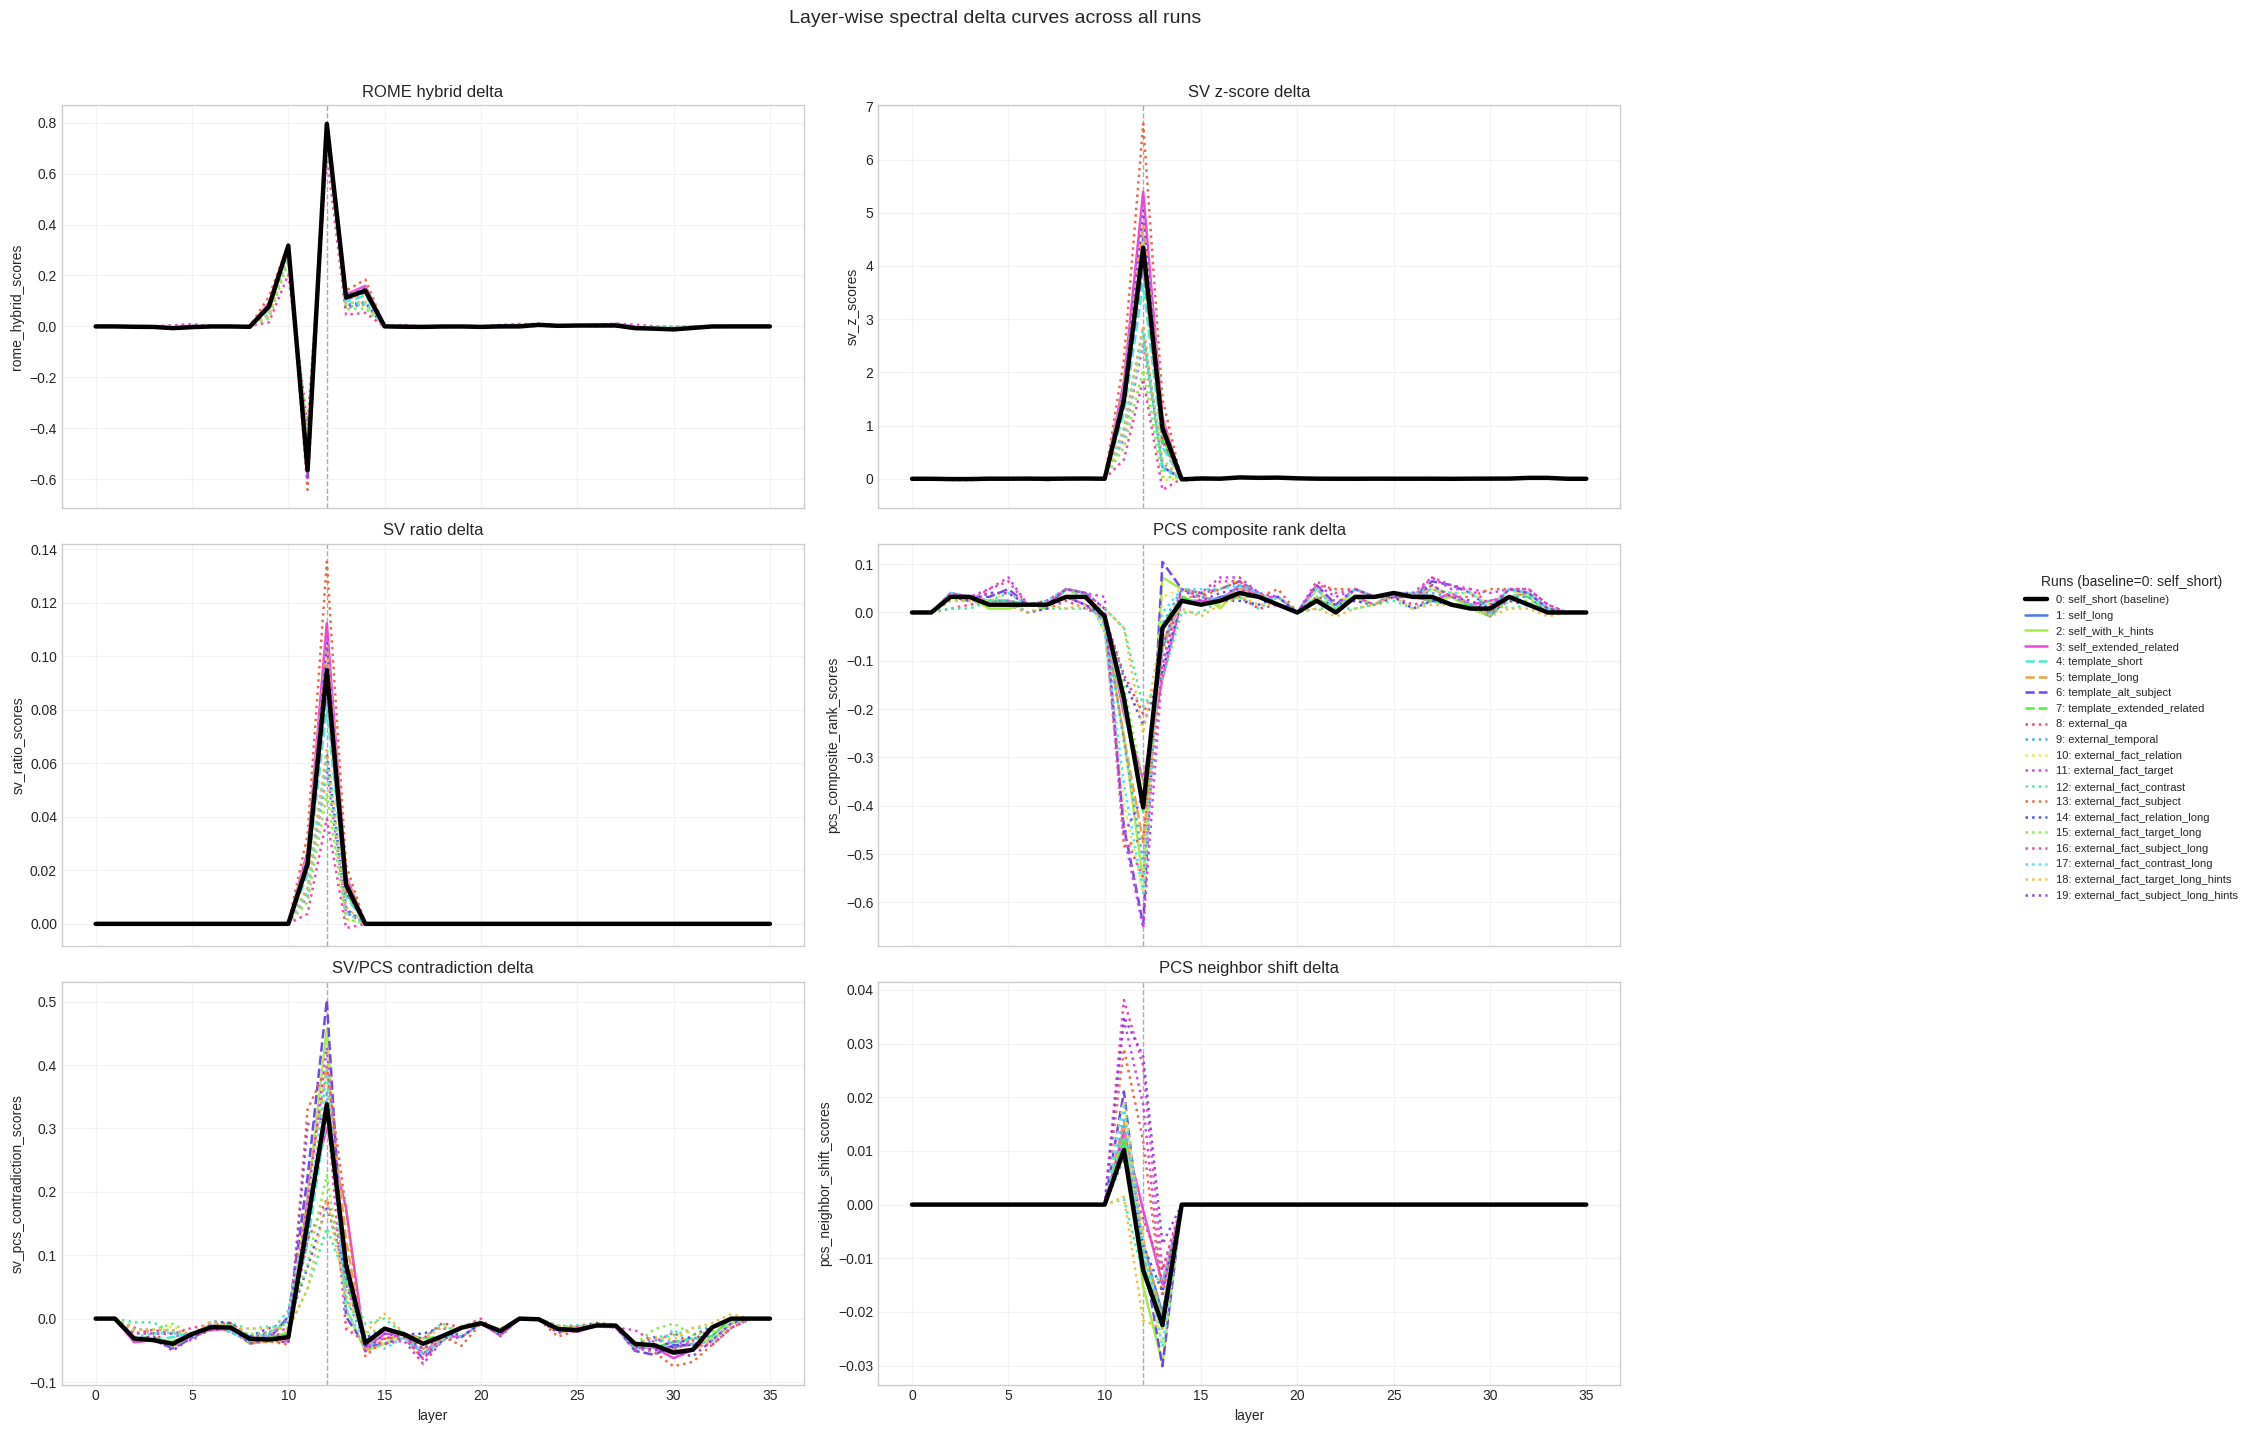

In [29]:
import colorsys
import matplotlib.patheffects as pe

metric_titles = {
    'rome_hybrid_scores': 'ROME hybrid delta',
    'sv_z_scores': 'SV z-score delta',
    'sv_ratio_scores': 'SV ratio delta',
    'pcs_composite_rank_scores': 'PCS composite rank delta',
    'sv_pcs_contradiction_scores': 'SV/PCS contradiction delta',
    'pcs_neighbor_shift_scores': 'PCS neighbor shift delta',
}

metrics_to_plot = list(metric_titles.items())
run_order = (
    df[['run_index', 'run_name', 'prefix_mode']]
    .drop_duplicates()
    .sort_values('run_index')
    .reset_index(drop=True)
)

# High-contrast colors using golden-ratio-spaced hues to keep adjacent runs visually distinct.
n_runs = max(len(run_order), 1)
hues = [((i * 0.618033988749895) % 1.0) for i in range(n_runs)]
palette = [colorsys.hsv_to_rgb(h, 0.78, 0.92) for h in hues]

run_colors = {
    int(run_order.iloc[i]['run_index']): palette[i]
    for i in range(len(run_order))
}

mode_linestyle = {
    'self': '-',
    'template': '--',
    'external': ':',
}

fig, axes = plt.subplots(3, 2, figsize=(20, 14), sharex=True)

for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
    for _, run in run_order.iterrows():
        run_index = int(run['run_index'])
        run_name = str(run['run_name'])
        prefix_mode = str(run['prefix_mode'])
        subset = layer_df[layer_df['run_index'] == run_index].sort_values('layer')
        if subset.empty:
            continue

        is_baseline = run_index == baseline_run_index
        label = f"{run_index}: {run_name}" + (' (baseline)' if is_baseline else '')

        line, = ax.plot(
            subset['layer'],
            subset[metric],
            color='black' if is_baseline else run_colors[run_index],
            linestyle='-' if is_baseline else mode_linestyle.get(prefix_mode, '-'),
            linewidth=3.2 if is_baseline else 1.8,
            alpha=1.0 if is_baseline else 0.9,
            label=label,
            zorder=6 if is_baseline else 3,
        )

        if not is_baseline:
            line.set_path_effects([
                pe.Stroke(linewidth=2.5, foreground='white', alpha=0.35),
                pe.Normal(),
            ])

    ax.axvline(edited_layer, color='gray', linestyle='--', linewidth=1.0, alpha=0.65)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.22)

for ax in axes[-1, :]:
    ax.set_xlabel('layer')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title=f'Runs (baseline={baseline_run_index}: {baseline_run_name})',
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=8,
)

plt.suptitle('Layer-wise spectral delta curves across all runs', y=1.02, fontsize=14)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [27]:
display_cols = [
    'run_index', 'run_name', 'prefix_mode', 'edited_layer_hybrid_score',
    'hybrid_margin_to_top', 'update_spectral_norm', 'target_prob_delta',
    'rome_hybrid_delta_at_edit_layer', 'sv_z_delta_at_edit_layer', 'sv_ratio_delta_at_edit_layer'
]
df[display_cols]

,run_index,run_name,prefix_mode,edited_layer_hybrid_score,hybrid_margin_to_top,update_spectral_norm,target_prob_delta,rome_hybrid_delta_at_edit_layer,sv_z_delta_at_edit_layer,sv_ratio_delta_at_edit_layer
0,0,self_short,self,1.296633,0.000000,7.878493,0.933838,0.795285,4.342592,0.094765
1,1,self_long,self,1.296085,0.000000,7.964428,0.937744,0.794737,4.534635,0.096385
2,2,self_with_k_hints,self,1.295023,0.000000,7.980649,0.937744,0.793675,4.446472,0.094657
3,3,self_extended_related,self,1.297395,0.000000,8.128304,0.937744,0.796047,5.392498,0.112378
4,4,template_short,template,1.290777,0.000000,7.715522,0.933838,0.789430,3.652222,0.080585
5,5,template_long,template,1.295633,0.000000,7.962770,0.933838,0.794285,4.802310,0.103350
6,6,template_alt_subject,template,1.288517,0.000000,7.818551,0.933838,0.787169,4.012011,0.087139
7,7,template_extended_related,template,1.293957,0.000000,7.834913,0.933838,0.792609,4.139027,0.089319
8,8,external_qa,external,1.297139,0.000000,7.892356,0.937744,0.795791,4.263471,0.091883
9,9,external_temporal,external,1.265627,0.000000,7.587357,0.933838,0.764279,2.722538,0.062462


In [28]:
summary = df.groupby('prefix_mode')[['edited_layer_hybrid_score', 'hybrid_margin_to_top', 'update_spectral_norm', 'target_prob_delta']].agg(['mean', 'std'])
summary

edited_layer_hybrid_score           hybrid_margin_to_top  \
                                 mean       std                 mean   
prefix_mode                                                            
external                     1.261329  0.034210             0.007018   
self                         1.296284  0.000997             0.000000   
template                     1.292221  0.003187             0.000000   

                      update_spectral_norm           target_prob_delta  \
                  std                 mean       std              mean   
prefix_mode                                                              
external     0.019845             7.749913  0.316855          0.934489   
self         0.000000             7.987968  0.103741          0.936768   
template     0.000000             7.832939  0.101413          0.933838   

                       
                  std  
prefix_mode            
external     0.005223  
self         0.001953  
template     0.000000